# Gas Monitoring Dataset — Exploratory Data Analysis

## Dataset Overview
Dataset captures environmental and sensor readings in an indoor workspace environment, whcih includes:

- **CO (Carbon Monoxide)** — odourless, invisible, highly dangerous gas
- **CO₂** — measured via infrared and electrochemical sensors
- **Metal Oxide Sensors (Units 1–4)** — react to CO and other gases
- **Temperature & Humidity** — environmental context
- **Ambient Light Level, Time of Day, HVAC Operation Mode, Activity Level** — contextual/categorical labels

**Target label for ML:** `Activity Level`

---
## 1. Import Libraries & Load Dataset

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# connect to database
conn = sqlite3.connect("gas_monitoring.db")

# read sample data
df = pd.read_sql_query("SELECT * FROM gas_monitoring;", conn)

# close connection after loading to prevent leakage
conn.close()

print(f"Dataset shape: {df.shape}") # shows no. of rows and columns
df.head() # first 5 rows of data

Dataset shape: (10000, 14)


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


---
# (EDA) Exploratory Data Analysis

---
## 1. Basic Data Analysis

In [ ]:
# summerises data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [ ]:
# describe numerical columns
df.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


In [ ]:
# checking for duplicated data
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 171


---
## 2. Analysis for Missing Data

In [ ]:
# quantify missing values per column
missing = df.isnull().sum() # no of rows of missing data
missing_pct = (missing / len(df) * 100).round(2) # convert to percentage

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}) # formats into a df
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))
# sorts df into msot to least percentage of missing data

                        Missing Count  Missing %
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
Ambient Light Level              1054      10.54
CO_GasSensor                      834       8.34


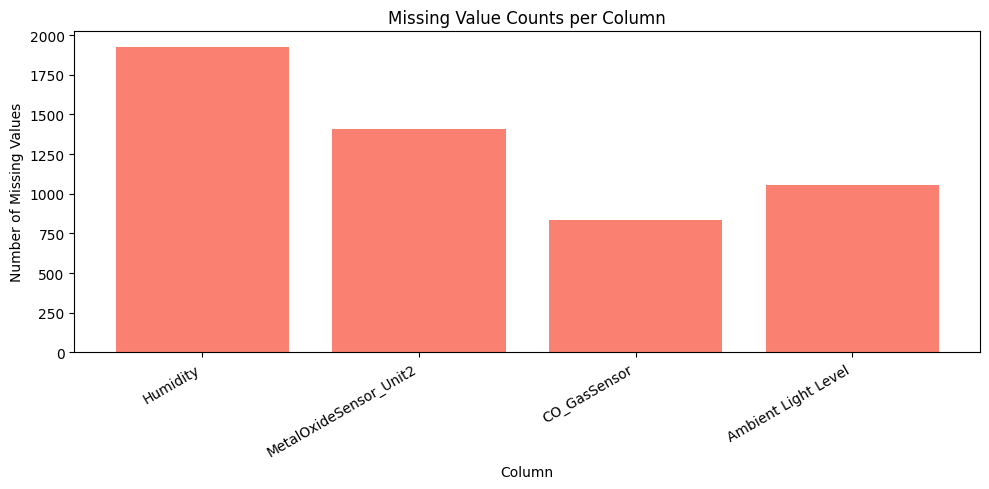

In [ ]:
# visualising missing data as a bar chart
missing_cols = missing[missing > 0]

plt.figure(figsize=(10, 5))
plt.bar(missing_cols.index, missing_cols.values, color='salmon')
plt.title('Missing Value Counts per Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation:**
- `Humidity` has the most missing values (~19.3%)
- `MetalOxideSensor_Unit2` is missing ~14.1%
- `Ambient Light Level` is missing ~10.5%
- `CO_GasSensor` has the least missing data (~8.3%)

**Rationale for Handling Missing Data (Imputing):**
- `CO_GasSensor`: Impute using MetalOxideSensor readings and CO₂ sensors (metal oxide reacts with CO; high CO₂ suppresses this reaction)
- `Ambient Light Level`: Impute using `Time of Day` (since it is only factor in the dataset that directly affects it)
- `Humidity`: Derive from `Time of Day` and `Temperature` (factors that affect humidity)
- `MetalOxideSensor_Unit2`: Derive from CO_GasSensor, CO₂ sensors

---
## 3. Session ID — Relevance Check

In [ ]:
# check for repeated Session IDs
print("Counts for 'Session ID':")
print(df['Session ID'].value_counts(dropna=False))

Counts for 'Session ID':
Session ID
6528    388
4703    387
3418    368
1374    362
5820    357
7058    350
3592    345
2105    341
2847    335
3856    335
7395    312
8936    309
1903    306
4507    301
1826    284
9385    280
2679    275
9658    266
4129    257
5693    255
9127    247
6431    245
7241    242
9184    241
8052    241
3074    235
9241    234
7963    232
8374    214
6817    198
5172    196
4761    178
1458    177
6847    175
5214    171
1482    161
8649    144
2586     56
Name: count, dtype: int64


**Observation:** `Session ID` repeats frequently with no meaningful correlation to other features. It will be dropped during preprocessing.

---
## 4. Numeric Feature Distributions

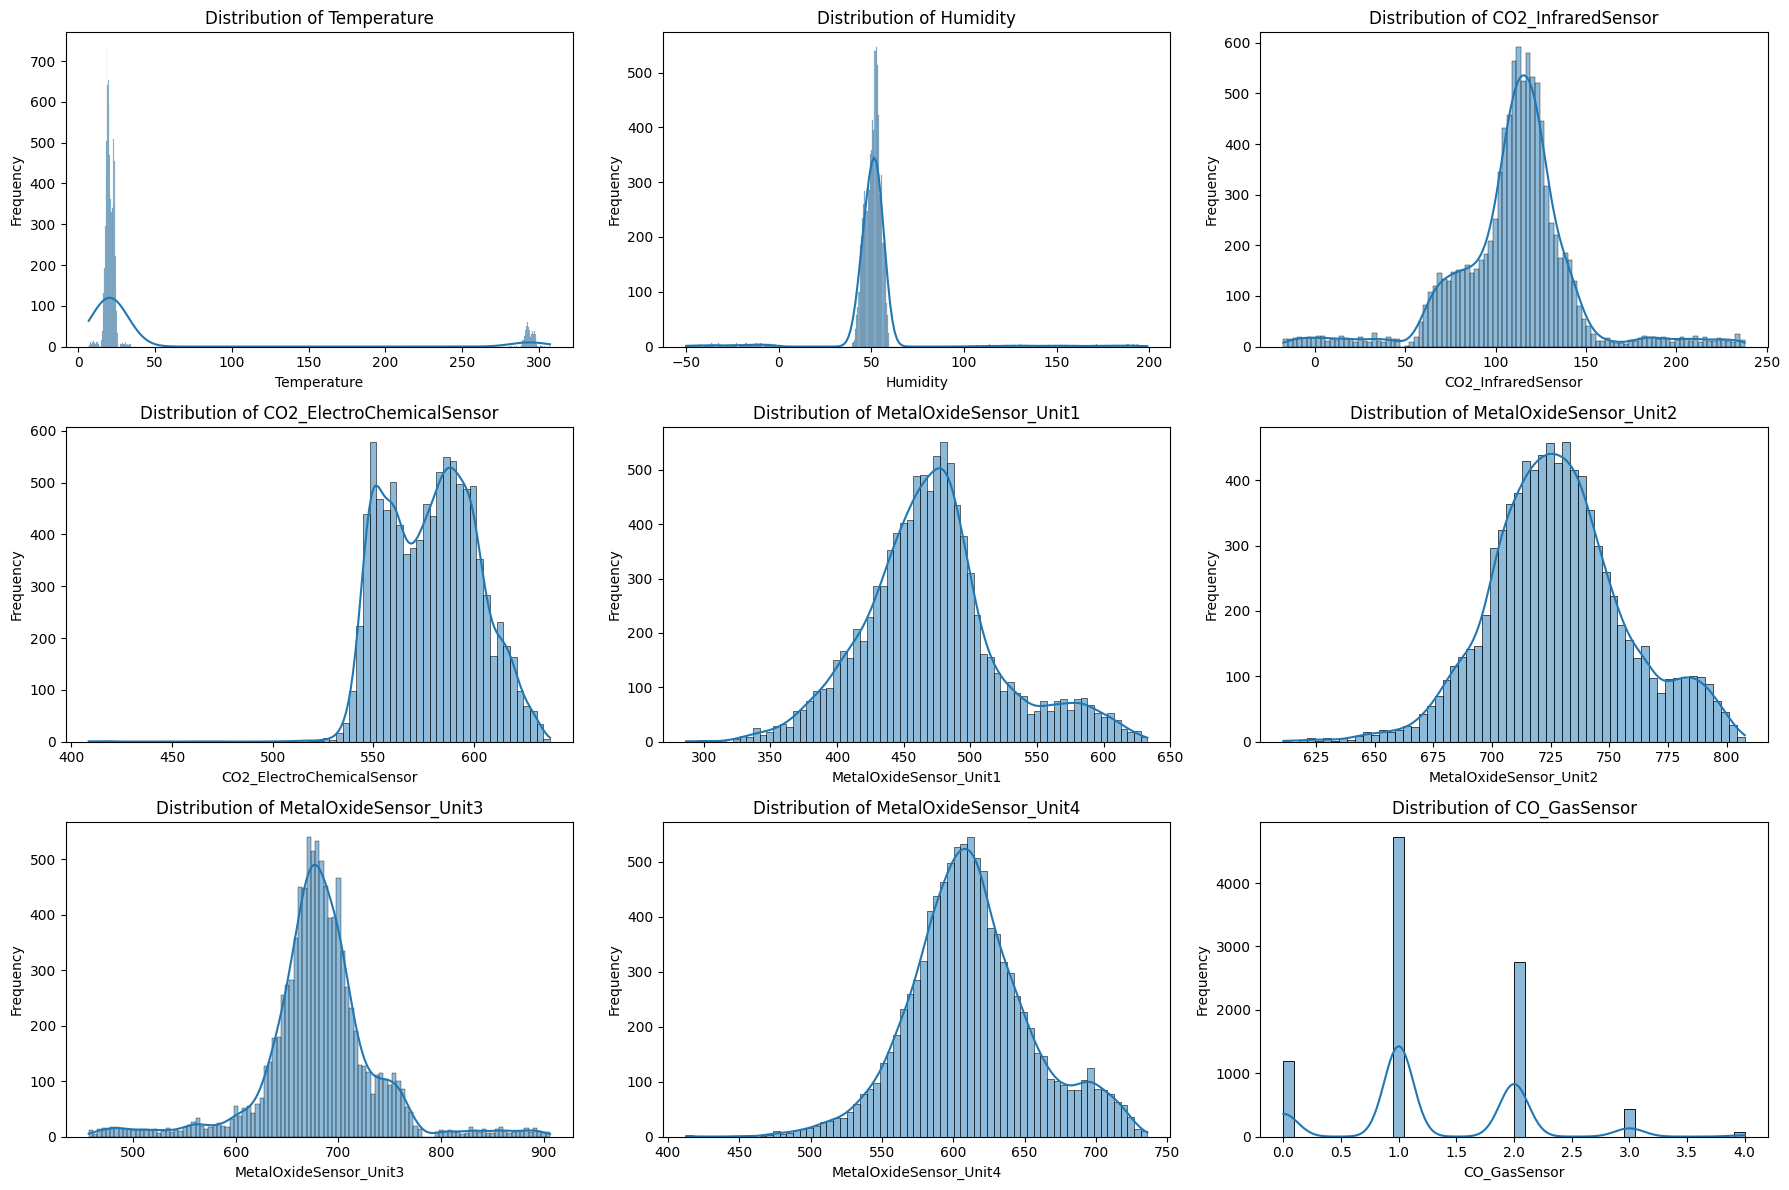

In [ ]:
# selects numeric columns, and exclues Session ID column
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns # selects numerical columns
if 'Session ID' in numeric_cols:
    numeric_cols = numeric_cols.drop('Session ID') # drops Session ID column

# creates a grid layout for all histograms instead of list down the graphs
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols)) # no. of numeric columns / no. of desired columns
# np.ceil or np ceiling rounds the number up if there is a floating point/remainder

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4)) # n_rows * 4 ensures subplots are visible despite more subplots added
axes = axes.flatten() # allows use of 1D instead of coordinates positioning like row, column [1, 2]

for i, col in enumerate(numeric_cols): # enumerate provides an increment i without needing to manually do i = 0, i += 1
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# hides any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.1 Temperature Anomaly — Kelvin vs Celsius

In [ ]:
# identify and quantify Kelvin readings (values clearly above ~60°C are likely Kelvin)
kelvin_threshold = 150  # values above this are almost certainly in Kelvin, middle ground between two peaks
kelvin_rows = df['Temperature'] > kelvin_threshold # gets the rows that are kelvin
print(f"Rows with Kelvin temperatures: {kelvin_rows.sum()} ({kelvin_rows.mean()*100:.1f}%)")
print(f"Min/Max of Kelvin-range values: {df.loc[kelvin_rows, 'Temperature'].min():.2f} / {df.loc[kelvin_rows, 'Temperature'].max():.2f}")
print(f"Equivalent Celsius range: {df.loc[kelvin_rows, 'Temperature'].min() - 273.15:.2f} / {df.loc[kelvin_rows, 'Temperature'].max() - 273.15:.2f}")

Rows with Kelvin temperatures: 795 (8.0%)
Min/Max of Kelvin-range values: 280.45 / 307.07
Equivalent Celsius range: 7.30 / 33.92


**Observation:** The `Temperature` column shows a bimodal distribution (has two distinct peaks):
- Main cluster around **20–25°C** — plausible indoor temperature in Celsius
- Secondary cluster around **293–298** — corresponds to 20–25°C converted to Kelvin (Celsius + 273.15)

**Analysis:** Some readings were recorded in Kelvin instead of Celsius.

**Rationale:** Convert Kelvin values back to Celsius before further analysis.

### 4.2 Humidity Anomaly — Out-of-Range Values


In [ ]:
# Quantify out-of-range humidity values
humidity_below_0 = (df['Humidity'] < 0).sum()
humidity_above_100 = (df['Humidity'] > 100).sum()

print(f"Humidity < 0%: {humidity_below_0} rows")
print(f"Humidity > 100%: {humidity_above_100} rows")
print(f"Total out-of-range: {humidity_below_0 + humidity_above_100} rows")
print()
print(df['Humidity'].describe())

Humidity < 0%: 207 rows
Humidity > 100%: 207 rows
Total out-of-range: 414 rows

count    8072.000000
mean       51.643609
std        21.333894
min       -49.870000
25%        47.660000
50%        51.390000
75%        53.840000
max       198.900000
Name: Humidity, dtype: float64


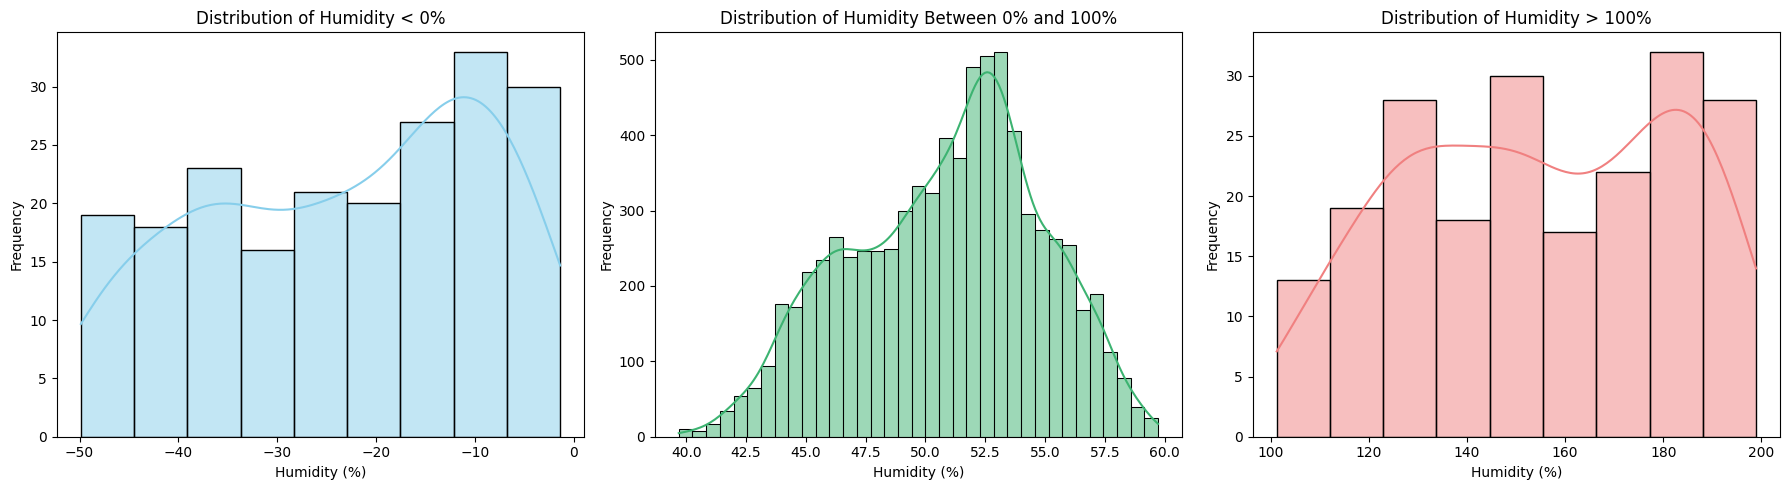

In [ ]:
# Filter humidity values less than 0%
humidity_less_than_0 = df[df['Humidity'] < 0]['Humidity'].dropna()

# Filter humidity values greater than 100%
humidity_greater_than_100 = df[df['Humidity'] > 100]['Humidity'].dropna()

# Filter humidity values between 0% and 100%
humidity_between_0_and_100 = df[(df['Humidity'] >= 0) & (df['Humidity'] <= 100)]['Humidity'].dropna()

plt.figure(figsize=(18, 5)) # Increased figure width for three subplots

plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, first plot
sns.histplot(humidity_less_than_0, kde=True, color='skyblue')
plt.title('Distribution of Humidity < 0%')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, second plot
sns.histplot(humidity_between_0_and_100, kde=True, color='mediumseagreen')
plt.title('Distribution of Humidity Between 0% and 100%')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns, third plot
sns.histplot(humidity_greater_than_100, kde=True, color='lightcoral')
plt.title('Distribution of Humidity > 100%')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observation:**
- `Humidity` values range from approximately **-50% to 199%**, which is physically impossible (valid range: 0–100%)
- Distribution of values out of the range does not reflect the valid range

**Rationale:**
- Out-of-range humidity values should be treated as missing data and imputed from `Temperature`.
- `Time of Day` not considered for imputation as it is indirectly related to Humidity through `Temperature`, that the dataset already has

### 4.3 Metal Oxide Sensors — Aggregation Consideration


In [ ]:
metal_oxide_cols = ['MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2',
                    'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4']

for col in metal_oxide_cols:
    median_value = df[col].median()
    print(f"Median for {col}: {median_value:.2f}")

Median for MetalOxideSensor_Unit1: 469.15
Median for MetalOxideSensor_Unit2: 726.75
Median for MetalOxideSensor_Unit3: 679.91
Median for MetalOxideSensor_Unit4: 609.53


In [ ]:
from numpy.linalg import norm
# import library to measure euclidean distance (length/magnitude of vector)
# needed to find cosine similarity
# less complex, easier to read for analysis compared to sklearn

sensor_cols = ['MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2',
               'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4']

# only use rows where all four sensors have data
df_sensors = df[sensor_cols].dropna()

print(f"Rows with all 4 sensor readings: {len(df_sensors)}\n")

# compute pairwise cosine similarity
print("Pairwise Cosine Similarity:")
for i in range(len(sensor_cols)):
    for j in range(i + 1, len(sensor_cols)):
        a = df_sensors[sensor_cols[i]].values
        b = df_sensors[sensor_cols[j]].values
        cos_sim = np.dot(a, b) / (norm(a) * norm(b)) # dot vector / (distance of A * B)

        # if >= 95% flag becomes aggregation recommendation
        # else flag = nothing and will not print out recommendation
        flag = " *** >= 95% — consider aggregating" if cos_sim >= 0.95 else ""
        print(f"  {sensor_cols[i]} vs {sensor_cols[j]}: {cos_sim:.4f}{flag}")

Rows with all 4 sensor readings: 8590

Pairwise Cosine Similarity:
  MetalOxideSensor_Unit1 vs MetalOxideSensor_Unit2: 0.9965 *** >= 95% — consider aggregating
  MetalOxideSensor_Unit1 vs MetalOxideSensor_Unit3: 0.9948 *** >= 95% — consider aggregating
  MetalOxideSensor_Unit1 vs MetalOxideSensor_Unit4: 0.9975 *** >= 95% — consider aggregating
  MetalOxideSensor_Unit2 vs MetalOxideSensor_Unit3: 0.9979 *** >= 95% — consider aggregating
  MetalOxideSensor_Unit2 vs MetalOxideSensor_Unit4: 0.9994 *** >= 95% — consider aggregating
  MetalOxideSensor_Unit3 vs MetalOxideSensor_Unit4: 0.9978 *** >= 95% — consider aggregating


**Observation**
- Data collected in each unit are bimodal with a large primary peak and a much smaller secondary peak
- Shape of the data is basically the same (approx 99.6%)
- Has differing medians

**Reasoning**
- Median differs likely as they were placed in different parts of the area of the same facility

**Rationale**
- Consider Aggregating into one column as a representation of overall metal oxide levels since the shape is the same



### 4.4 CO2 Sensors — Anomalies & Veracity of CO2 Infrared Sensor

In [ ]:
co2_infrared_less_than_0 = (df['CO2_InfraredSensor'] < 0).sum()
print(f"Number of CO2_InfraredSensor readings less than 0: {co2_infrared_less_than_0}")

Number of CO2_InfraredSensor readings less than 0: 113


In [ ]:
from numpy.linalg import norm

co2_sensor_cols = ['CO2_InfraredSensor', 'CO2_ElectroChemicalSensor']

# Calculate cosine similarity
a = df['CO2_InfraredSensor'].values
b = df['CO2_ElectroChemicalSensor'].values

# Check if either array is all zeros to avoid division by zero
if norm(a) == 0 or norm(b) == 0:
    print("Cannot compute cosine similarity: one or both CO2 sensor series contain all zero values.")
else:
    cos_sim_co2 = np.dot(a, b) / (norm(a) * norm(b))

    # Check for aggregation recommendation
    aggregation_threshold = 0.80 # 80%
    flag = " *** >= 80% — consider aggregating" if cos_sim_co2 >= aggregation_threshold else ""

    print(f"Cosine Similarity between CO2_InfraredSensor and CO2_ElectroChemicalSensor: {cos_sim_co2:.4f}{flag}")

Cosine Similarity between CO2_InfraredSensor and CO2_ElectroChemicalSensor: 0.9514 *** >= 80% — consider aggregating


**Observation**
- Despite both sensors detecting the same thing, they show very different results:
  - Peaks:
    - ElectroChemical Sensor: Two Strong Peaks of CO2 Levels
    - IR Sensor: One Strong 1 Weak Peak of Co2 Levels
  - Presence of Anomalies
    - ElectroChemical Sensor: No visible anomalies found on the graph
    - IR Sensor: Some data distributed across the ranges from less than 0 to 240 despite peaking at 120
- However, using cosine simlarity, the shape of the graph is relatively the same (approx 95%)

**Reasoning**
- IR Sensor detects CO2 Levels by measuirng how much light is absored by CO2
- When Temperature increases, air expands and there is less CO2 in the detected area, creating a perceived lower CO2 level
- Results, in abnormal CO2 Levels dtected by IR Sensor

**Rationale**
- Use Interquartile Range to filter out abnormalities in IR Sensor Data, especially CO2 Levels < 0
- Aggregate remaining data into CO2 Level (Requires scaling due to difference in how they are measure in magnitude)


---
## 5. Outlier Detection with Boxplots

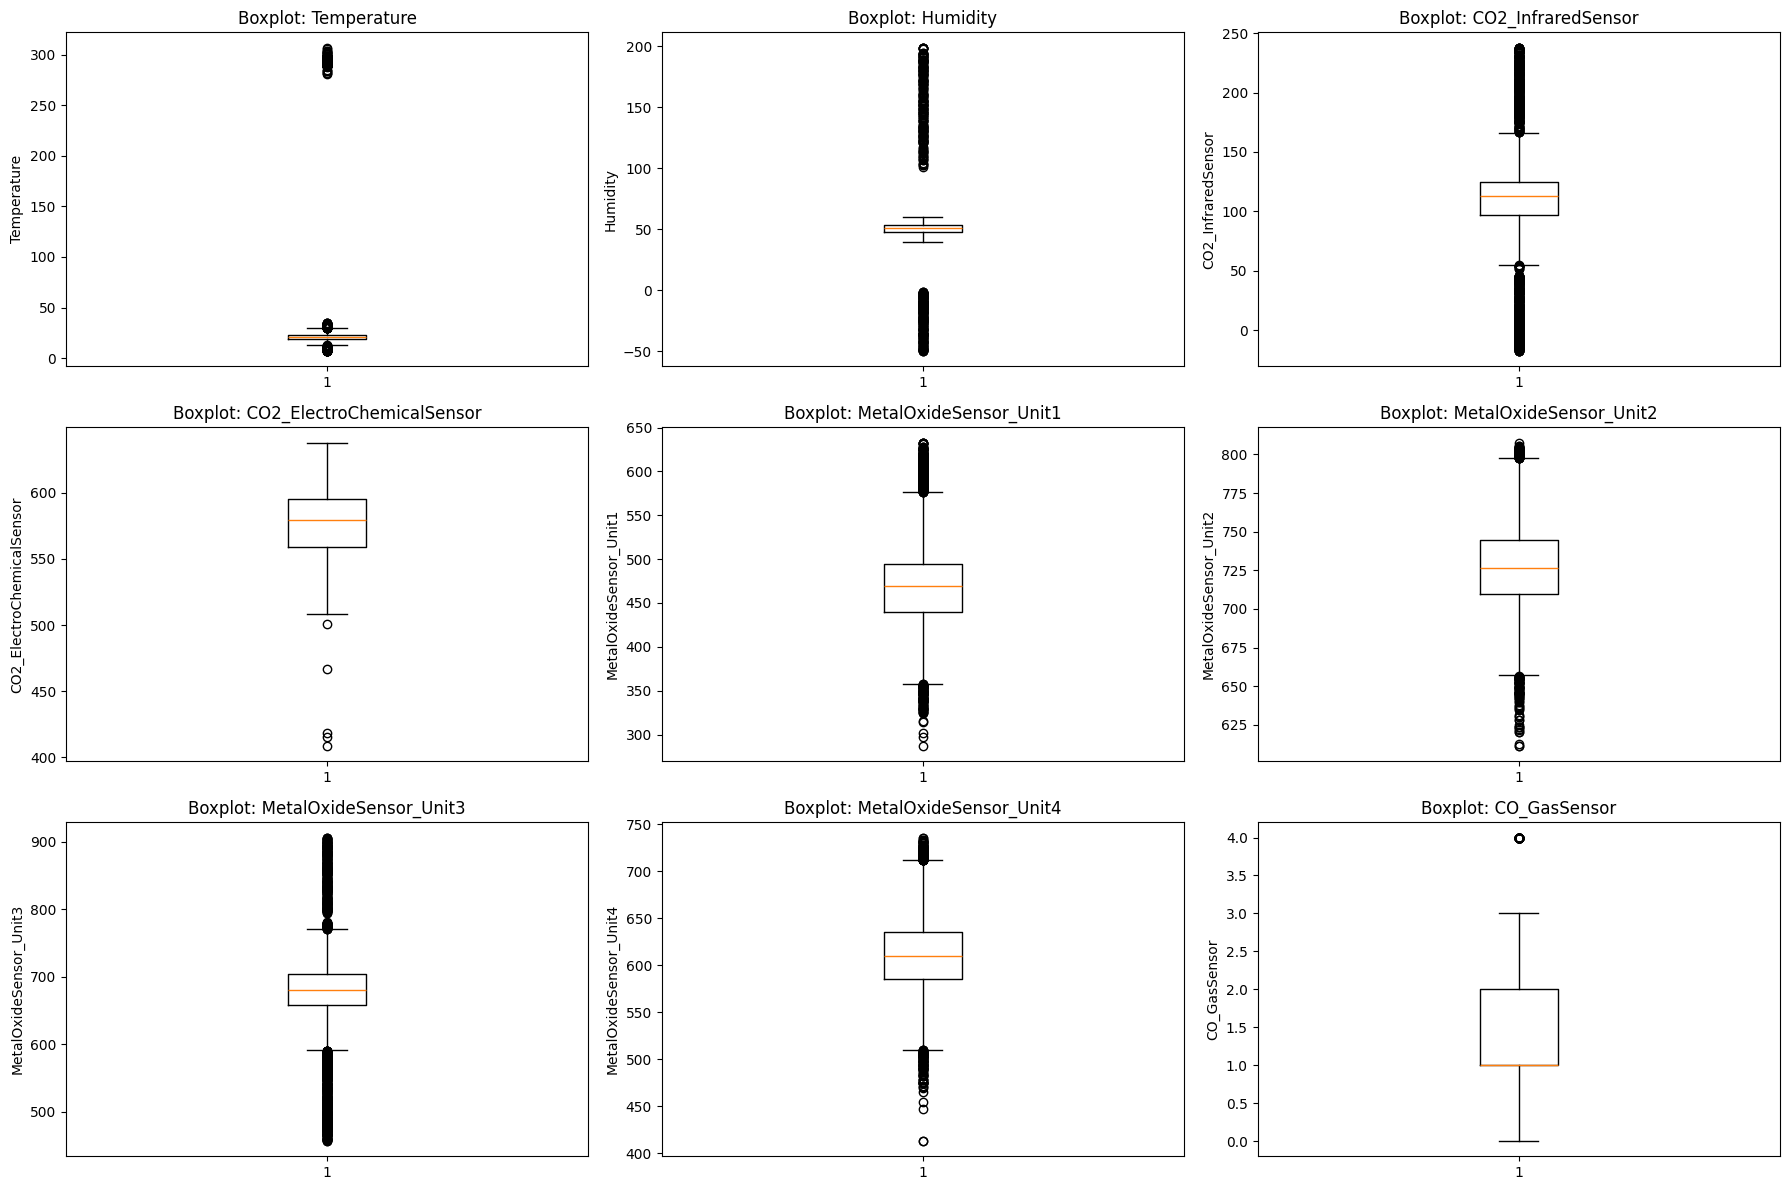

In [ ]:
# boxplots to detect outliers in numeric features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True) # vert refers to vertical (boxplot)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Categorical Feature Analysis

In [ ]:
categorical_cols = ['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level', 'CO_GasSensor']

for col in categorical_cols:
    print(f"\n--- Class Counts for '{col}': ---")
    print(df[col].value_counts(dropna=False))


--- Class Counts for 'Time of Day': ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64

--- Class Counts for 'HVAC Operation Mode': ---
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
VENTILATION_ONLY      98
HEATING_ACTIVE        98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64

--- Class Counts for 'Ambient Light Level': ---
Ambient Light Level
very_bright    3387
bright         2697
moderate       1463
None           1054
dim             864
very_dim  

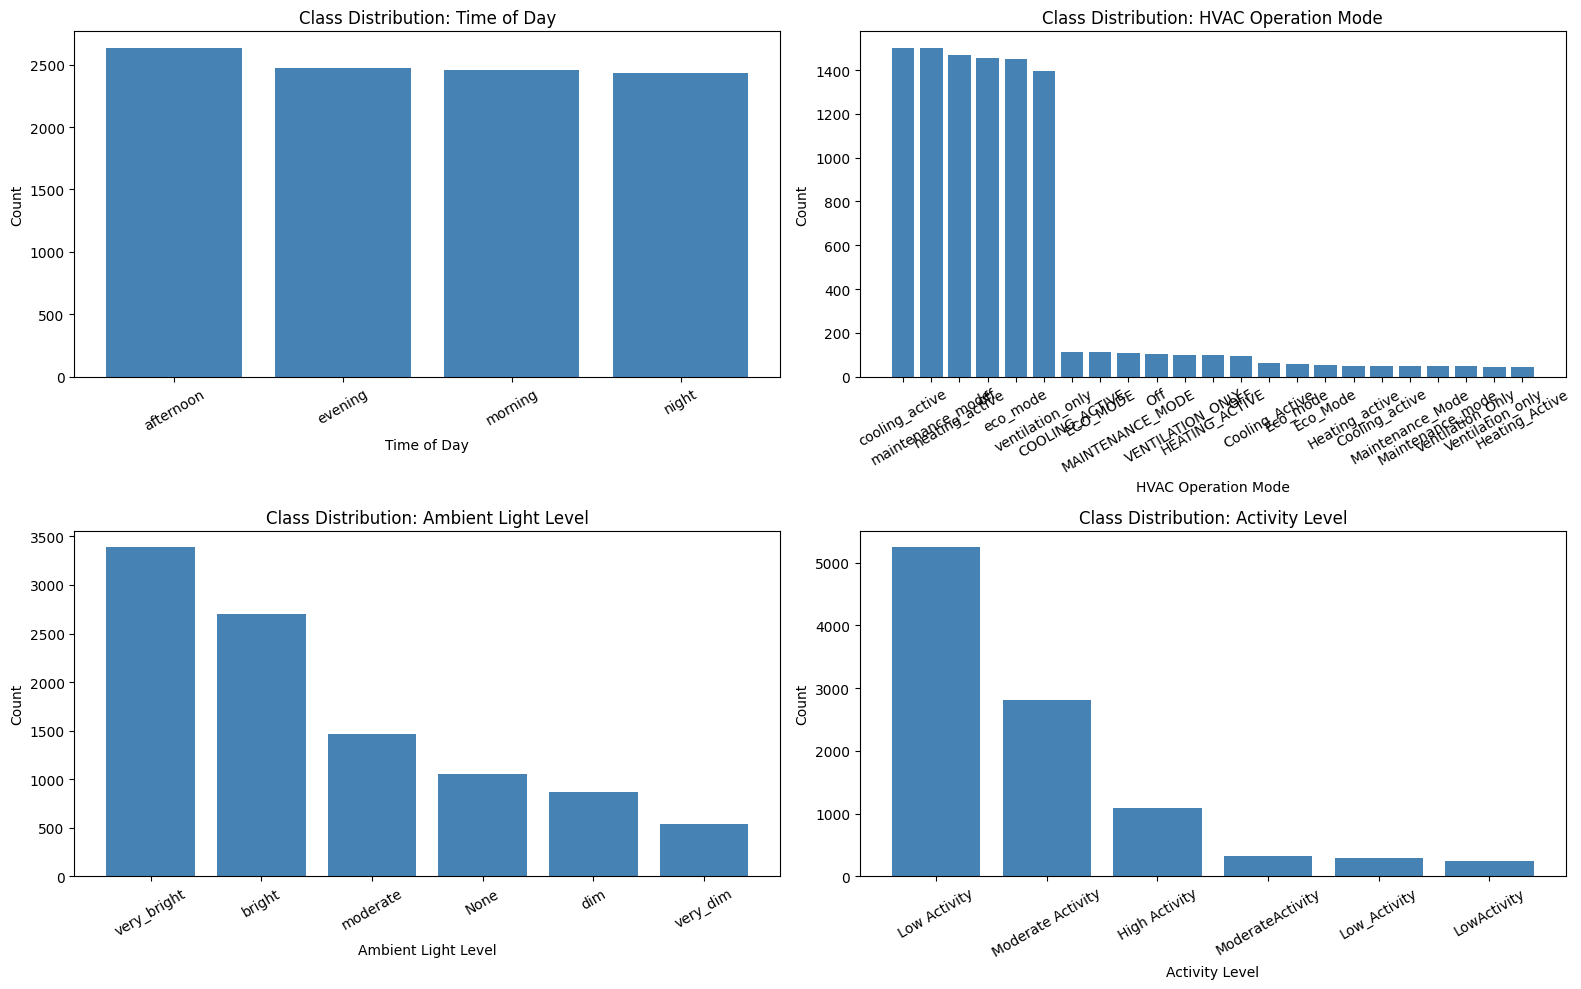

In [ ]:
# visualise categorical distributions as bar charts
cat_plot_cols = ['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    counts = df[col].value_counts(dropna=False)
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue')
    axes[i].set_title(f'Class Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations:**
- **Activity Level:** `Low Activity` has significantly more rows than `Moderate Activity` and `High Activity` — class imbalance exists
- **HVAC Operation Mode:** inconsistent naming — `Ventilation_Only` vs `Ventilation_only` vs `ventilation_only`,`COOLING_ACTIVE` vs `Cooling_Active` standardise by make all lowercase — data uniformity issue
- **Activity Level:** `LowActivity` vs `Low Activity` vs `Low_Activity` standardised by separating with underscore — data uniformity issue

**Rationale**
- make all the categorical data lowercase, with words separated with underscore


---
## 10. Pearson Correlation Heatmap

Data Cleaning for Visualisation

In [ ]:
df_clean = df.copy()

# make all cell data lowercase and replace spaces with underscores
df_clean = df_clean.map(lambda x: x.lower() if isinstance(x, str) else x) # lowercase
df_clean = df_clean.map(lambda x: x.lower().replace(' ', '_') if isinstance(x, str) else x) # strip spaces to underscores

# add spacing to values for data consistency
df_clean['Activity Level'] = df_clean['Activity Level'].replace('lowactivity',
                                                    'low_activity')
df_clean['Activity Level'] = df_clean['Activity Level'].replace('moderateactivity',
                                                'moderate_activity')

df_clean['Temperature'] = np.where(df_clean['Temperature'] > 150, # if temp > 150
                             df_clean['Temperature'] - 273.15, # then temp - 273.15
                             df_clean['Temperature']) # unchanged if condition unmet

In [ ]:
print("--- df_clean.info() ---")
df_clean.info()
print("\n--- df_clean.describe() ---")
df_clean.describe()

print("\n--- Duplicates in df_clean ---")
print(f"Duplicates: {df_clean.duplicated().sum()}")

print("\n--- Unique values for key categorical columns in df_clean ---")
print("HVAC Operation Mode:")
print(df_clean['HVAC Operation Mode'].value_counts())
print("\nAmbient Light Level:")
print(df_clean['Ambient Light Level'].value_counts())
print("\nActivity Level:")
print(df_clean['Activity Level'].value_counts())

print("\n--- Humidity Out-of-Range in df_clean (after temperature correction) ---")
humidity_below_0_clean = (df_clean['Humidity'] < 0).sum()
humidity_above_100_clean = (df_clean['Humidity'] > 100).sum()
print(f"Humidity < 0% in df_clean: {humidity_below_0_clean} rows")
print(f"Humidity > 100% in df_clean: {humidity_above_100_clean} rows")

--- df_clean.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level         

## Further Analysis

---
### CO2 Sensor Analysis by Activity Level

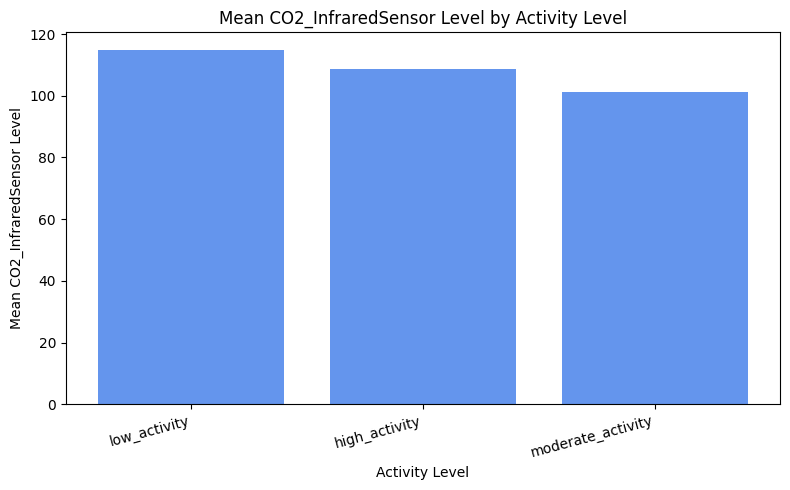

Percentage decrease in CO2_InfraredSensor from 'low_activity' to 'high_activity': 5.25%
Percentage decrease in CO2_InfraredSensor from 'low_activity' to 'moderate_activity': 11.88%


In [ ]:
# CO2_InfraredSensor levels grouped by Activity Level
plt.figure(figsize=(8, 5))
activity_co2_infrared = df_clean.groupby('Activity Level')['CO2_InfraredSensor'].mean().sort_values(ascending=False)
plt.bar(activity_co2_infrared.index.astype(str), activity_co2_infrared.values, color='cornflowerblue')
plt.title('Mean CO2_InfraredSensor Level by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Mean CO2_InfraredSensor Level')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Calculate percentage decrease from low activity level for CO2_InfraredSensor
low_activity_co2_infrared_mean = activity_co2_infrared.loc['low_activity']
high_activity_co2_infrared_mean = activity_co2_infrared.loc['high_activity']
moderate_activity_co2_infrared_mean = activity_co2_infrared.loc['moderate_activity']

percentage_decrease_high_co2_infrared = ((low_activity_co2_infrared_mean - high_activity_co2_infrared_mean) / low_activity_co2_infrared_mean) * 100
percentage_decrease_moderate_co2_infrared = ((low_activity_co2_infrared_mean - moderate_activity_co2_infrared_mean) / low_activity_co2_infrared_mean) * 100

print(f"Percentage decrease in CO2_InfraredSensor from 'low_activity' to 'high_activity': {percentage_decrease_high_co2_infrared:.2f}%")
print(f"Percentage decrease in CO2_InfraredSensor from 'low_activity' to 'moderate_activity': {percentage_decrease_moderate_co2_infrared:.2f}%")

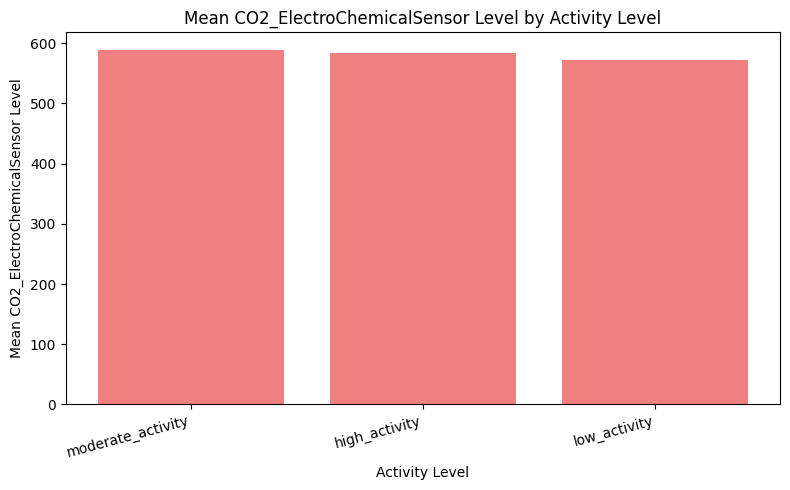

Percentage decrease in CO2_ElectroChemicalSensor from 'low_activity' to 'high_activity': -2.14%
Percentage decrease in CO2_ElectroChemicalSensor from 'low_activity' to 'moderate_activity': -2.93%


In [ ]:
# CO2_ElectroChemicalSensor levels grouped by Activity Level
plt.figure(figsize=(8, 5))
activity_co2_electrochemical = df_clean.groupby('Activity Level')['CO2_ElectroChemicalSensor'].mean().sort_values(ascending=False)
plt.bar(activity_co2_electrochemical.index.astype(str), activity_co2_electrochemical.values, color='lightcoral')
plt.title('Mean CO2_ElectroChemicalSensor Level by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Mean CO2_ElectroChemicalSensor Level')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Calculate percentage decrease from low activity level for CO2_ElectroChemicalSensor
low_activity_co2_electrochemical_mean = activity_co2_electrochemical.loc['low_activity']
high_activity_co2_electrochemical_mean = activity_co2_electrochemical.loc['high_activity']
moderate_activity_co2_electrochemical_mean = activity_co2_electrochemical.loc['moderate_activity']

percentage_decrease_high_co2_electrochemical = ((low_activity_co2_electrochemical_mean - high_activity_co2_electrochemical_mean) / low_activity_co2_electrochemical_mean) * 100
percentage_decrease_moderate_co2_electrochemical = ((low_activity_co2_electrochemical_mean - moderate_activity_co2_electrochemical_mean) / low_activity_co2_electrochemical_mean) * 100

print(f"Percentage decrease in CO2_ElectroChemicalSensor from 'low_activity' to 'high_activity': {percentage_decrease_high_co2_electrochemical:.2f}%")
print(f"Percentage decrease in CO2_ElectroChemicalSensor from 'low_activity' to 'moderate_activity': {percentage_decrease_moderate_co2_electrochemical:.2f}%")

**Hypothesis**
- higher the `Activity Level`, higher the `CO2 Level` as more people are there to breathe out CO2
- thus, `CO2 Level` would positively correlate with `Activity Level`

**Observation**
- From `low_activity` to `high_activity` there is a decrease instead of an increase of `CO_Level`
- No strong correlation with plausible negative correlation instead

---
### Temperature Analysis by Time of Day

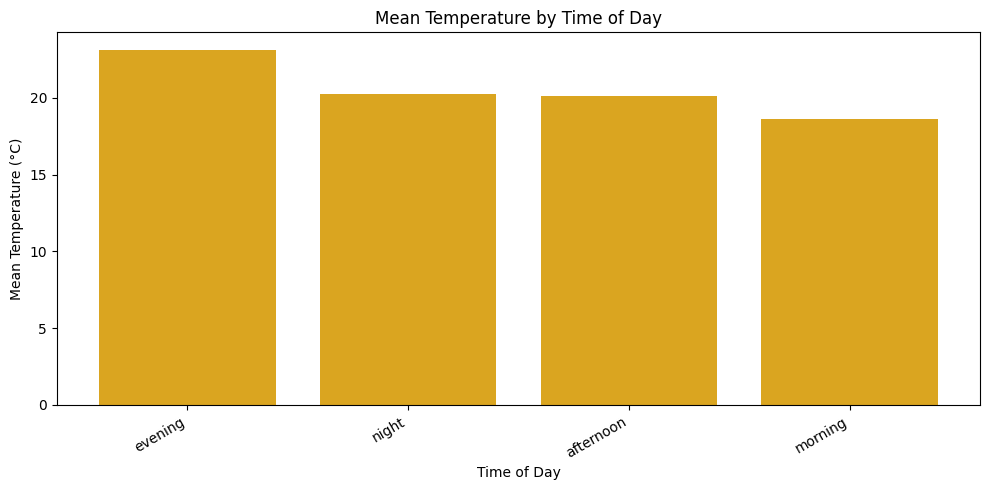

In [ ]:
# Temperature by Time of Day — supports humidity imputation strategy
plt.figure(figsize=(10, 5))
tod_temp = df_clean.groupby('Time of Day')['Temperature'].mean().sort_values(ascending=False)
plt.bar(tod_temp.index.astype(str), tod_temp.values, color='goldenrod')
plt.title('Mean Temperature by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Mean Temperature (°C)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Pearson's Correlation Matrix

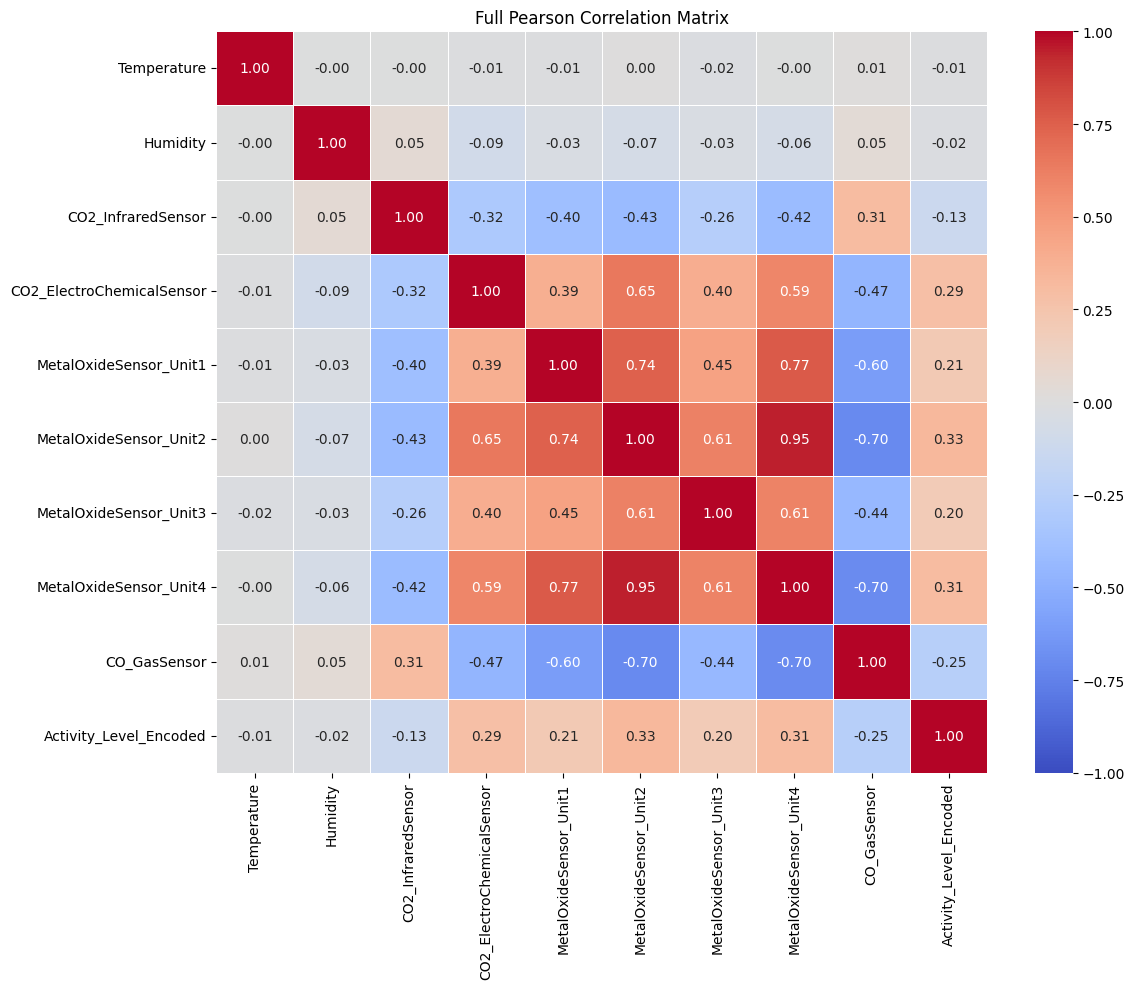

In [ ]:
# Ordinally encode Activity Level for Pearson correlation
dfv_ordinal_activity = df_clean.copy()
dfv_ordinal_activity = dfv_ordinal_activity.drop('Session ID', axis=1)

activity_mapping = {'low_activity': 0, 'moderate_activity': 1, 'high_activity': 2}
dfv_ordinal_activity['Activity_Level_Encoded'] = dfv_ordinal_activity['Activity Level'].map(activity_mapping)
dfv_ordinal_activity = dfv_ordinal_activity.drop('Activity Level', axis=1)

# Full Pearson correlation matrix (numeric columns only)
numeric_df_ordinal = dfv_ordinal_activity.select_dtypes(include=["number"])
corr_matrix = numeric_df_ordinal.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Full Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

### Pearson's Correlation Matrix (Focused on Activity Level for ML)

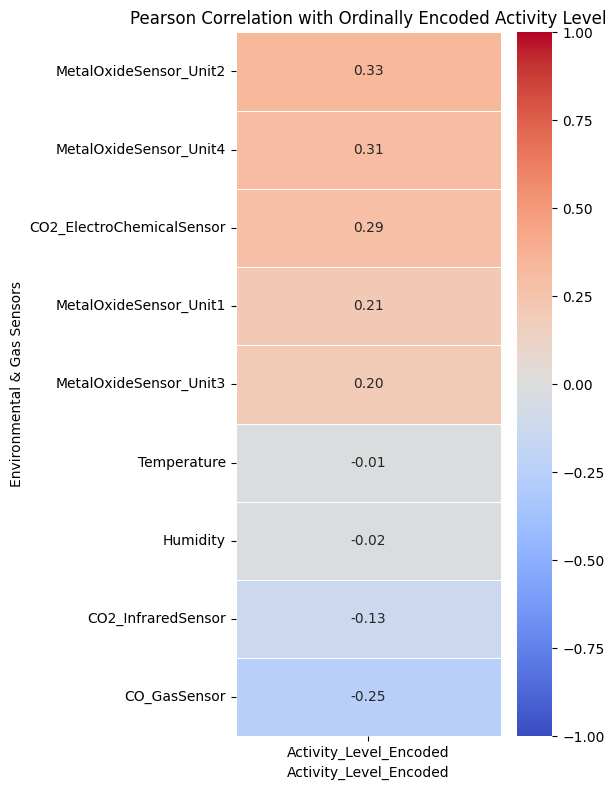

In [ ]:
# Focused: Pearson correlation of all features with Activity_Level_Encoded
activity_level_corr = corr_matrix[['Activity_Level_Encoded']].drop('Activity_Level_Encoded', axis=0)
activity_level_corr = activity_level_corr.sort_values('Activity_Level_Encoded', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(
    activity_level_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Pearson Correlation with Ordinally Encoded Activity Level")
plt.xlabel("Activity_Level_Encoded")
plt.ylabel("Environmental & Gas Sensors")
plt.tight_layout()
plt.show()

---
## 11. EDA Summary & Preprocessing Rationale

---

### Observations
- Dataset captures CO, CO₂, metal oxide, temperature, humidity, light, activity, and HVAC data across 10,000 rows

- Missing data exists in:
  - Humidity (approx 19.3%),
  - MetalOxideSensor_Unit2 (approx 14.1%),
  - Ambient Light Level (approx 10.5%),
  - CO_GasSensor (approx 8.3%)
  - Temperature has a unit inconsistency — some readings are in Kelvin- Humidity has out-of-range values (< 0% or > 100%)

- Categorical columns have inconsistent naming conventions, now standardized in `df_clean`- `CO2_InfraredSensor` contains physically impossible negative values (113 rows identified)

- While `CO2_InfraredSensor` and `CO2_ElectroChemicalSensor` show different distributions, their underlying patterns are highly similar (cosine similarity ~95%), suggesting they measure the same phenomenon.

- Metal oxide sensor data units are highly correlated (pairwise cosine similarity > 99.6%), indicating they measure similar phenomena, likely from different locations.

---

### Preprocessing Rationale

**Column Ordering:**

- Drop `Session ID` (no predictive value)- Move `Activity Level` to the rightmost column (ML target)

- Place `CO_GasSensor` first

- Group `Temperature` and `Humidity` together (correlated environmental features)

- Group categorical columns to the right


**Data Type Conversions:**

- Removing the null values will not automatically convert it back to the desired dtype, requires manual conversion- `CO_GasSensor`: object → int

- `Time of Day`, `HVAC Operation Mode`, `Ambient Light Level`, `Activity Level`: object → string**Data Uniformity:**

- Standardize categorical column entries to lowercase with underscores (`df_clean` already shows this applied).


**Handling Missing Data (Imputation):**
- `CO_GasSensor`: Impute using metal oxide and CO₂ sensor readings.

- `Ambient Light Level`: Impute using `Time of Day`.
- `Humidity`: Treat out-of-range values (<0% or >100%) as missing and impute from `Temperature`.

- `MetalOxideSensor_Unit2`: Impute using `CO2_ElectroChemicalSensor` and `CO_GasSensor`

**Handling Anomalies:**

- `Temperature`: Convert Kelvin readings to Celsius.

- `CO2_InfraredSensor`: Treat negative values as anomalies; these will be set to NaN and imputed later (or capped at 0 before imputation). The discrepancy with `CO2_ElectroChemicalSensor` implies careful handling or aggregation after scaling is needed.

**Feature Engineering:**

-  Aggregate Metal Oxide Sensors into a single feature (e.g., `MetalOxideSensor_Aggregated` or `Overall Metal Oxide Levels`).

- Aggregate CO2 Sensors into a single feature (e.g., `CO2_Aggregated`), potentially after scaling to normalize their different magnitudes.

- `Time of Day` → Integer Encoding (ordered by time ranges)

- `HVAC Operation Mode` → One-Hot Encoding (distinct, unordered classes)

- `Ambient Light Level` → Integer Encoding (ordered by intensity levels)

- `Activity Level` → Integer Encoding (ordered by intensity levels for ML target)